# Individual Assignment 2  Due Date Dec 9, 9 am

# ============================================
# Case Study 2 – Nonlinear Models for Retention
# Pilgrim Bank (B): Customer Retention
# ============================================

Pilgrim Bank is debating whether to invest in a targeted campaign that encourages customers to adopt online banking.
Working with the 1999 customer dataset from the case packet, we examine how profit varies across online and offline
users while accounting for demographic and relationship factors highlighted in the brief. We follow the analytic steps
to build quantitative evidence that informs Pilgrim Bank's marketing decision.

# To Do Now:
Objective: The objective of this Case Study is to extend Case Study 2 by implementing and evaluating nonlinear ML models instead of logistic regression. Compare performance, discuss findings, and reflect on whether these models improve on the original baseline.
Models to implement (at minimum):
# Models 
A.	Decision Tree
B.	KNN
C.	Random Forest
D.	Support Vector Machine (SVM)
E.	XGBoost

# In this Notebook(.ipynb) I aim to do the following:
1. Prepares data (renaming, missingness flags, imputation, scaling, one-hot encoding).

2. Trains and tunes Decision Tree, Random Forest, SVR, XGBoost via GridSearchCV.

3. Evaluates each model and compares against the linear regression baseline.

4. Provides feature importance plots (RF + XGBoost) and a learning curve for XGBoost that you can discuss in terms of bias–variance and nonlinearity.


In [1]:
# Install required packages
%pip install pandas numpy matplotlib seaborn scikit-learn statsmodels --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


# -------------------------
# 0. Setup: imports & config
# -------------------------

In [5]:

# Import required libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    learning_curve
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    RocCurveDisplay
)

# Define constants
RANDOM_STATE = 2025
DATA_PATH = "PilgrimDataA.csv"

# ============================================
# 1. Data preparation
# ============================================

In [7]:
# 1.1 Load data

df_raw = pd.read_csv("PilgrimDataA.csv")
# df_raw = pd.read_excel(DATA_PATH)  # or pd.read_csv("PilgrimBank_B.csv")
print("Original columns:\n", df_raw.columns.tolist())

# 1.2 Rename columns to readable names (adjust if your file is different)
# ------------------------------------------------
col_map = {
    "9Profit": "profit_1999",
    "0Profit": "profit_2000",
    "9Online": "online_1999",
    "0Online": "online_2000",
    "9Age": "age_1999",
    "9Inc": "income_1999",
    "9Tenure": "tenure",
    "9District": "district",
    "9Billpay": "billpay_1999",
    "0Billpay": "billpay_2000",
}
df = df_raw.rename(columns={c: col_map.get(c, c) for c in df_raw.columns})

print("\nAfter renaming:\n", df.columns.tolist())


Original columns:
 ['ID', '9Profit', '9Online', '9Age', '9Inc', '9Tenure', '9District', '0Profit', '0Online', '9Billpay', '0Billpay']

After renaming:
 ['ID', 'profit_1999', 'online_1999', 'age_1999', 'income_1999', 'tenure', 'district', 'profit_2000', 'online_2000', 'billpay_1999', 'billpay_2000']


# 1.3. Create target variable: Retention (1 = stayed, 0 = left)
# 1.4. Basic exploration plot: Retention distribution 
# 1.5. select features and Handling Missing Values 



Retention distribution:
 Retention
1    0.835019
0    0.164981
Name: proportion, dtype: float64


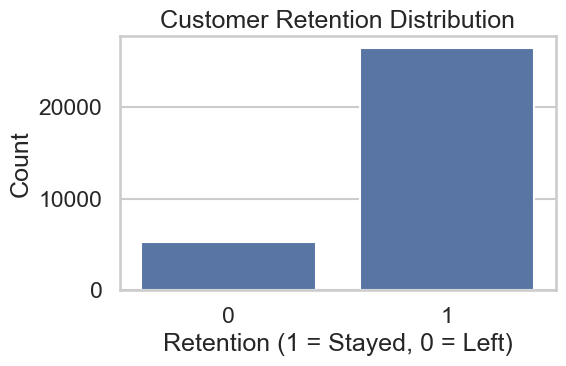

In [10]:
# 1.3 Create target variable: Retention (1 = stayed, 0 = left)
# ------------------------------------------------
# A simple rule: if online_2000 (or profit_2000) is missing, assume customer left.
df["Retention"] = (~df["online_2000"].isna()).astype(int)

print("\nRetention distribution:\n", df["Retention"].value_counts(normalize=True))

# 1.4 Basic exploration (plot retention distribution)
# ------------------------------------------------
plt.figure(figsize=(6, 4))
sns.countplot(x="Retention", data=df)
plt.title("Customer Retention Distribution")
plt.xlabel("Retention (1 = Stayed, 0 = Left)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 1.5 Select features
# ------------------------------------------------

feature_cols = [
    "profit_1999",
    "online_1999",
    "billpay_1999",
    "age_1999",
    "income_1999",
    "tenure",
    "district",
] 
# Keep only rows with non-missing target
df_model = df[feature_cols + ["Retention"]].copy()
df_model = df_model.dropna(subset=["Retention"])

X = df_model[feature_cols]
y = df_model["Retention"]

# 1.6 Identify column types for preprocessing 
# 1.7 Train/validation/test split
#  1.8 Preprocessing pipeline

In [12]:


# 1.6 Identify column types for preprocessing
# ------------------------------------------------
numeric_features = ["profit_1999", "online_1999", "billpay_1999",
                   "age_1999", "income_1999", "tenure"]
categorical_features = ["district"]

# 1.7 Train/validation/test split
# ------------------------------------------------
# First split into train+val and final test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# Split train_val again into train/val inside CV (using StratifiedKFold)
print("Train+Val shape:", X_train_val.shape)
print("Test shape:", X_test.shape)

# 1.8 Preprocessing pipeline
# ------------------------------------------------
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

Train+Val shape: (25307, 7)
Test shape: (6327, 7)


# ============================================
# 2. Baseline: Logistic Regression
# ============================================

In [13]:
# ============================================
# 2. Baseline: Logistic Regression
# ============================================

log_reg_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced",
                                   random_state=RANDOM_STATE)),
    ]
)

log_reg_pipe.fit(X_train_val, y_train_val)

y_train_val_pred = log_reg_pipe.predict(X_train_val)
y_train_val_proba = log_reg_pipe.predict_proba(X_train_val)[:, 1]

y_test_pred = log_reg_pipe.predict(X_test)
y_test_proba = log_reg_pipe.predict_proba(X_test)[:, 1]

def evaluate_classification(y_true, y_pred, y_proba, label="model"):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_proba)
    print(f"{label} -> ACC: {acc:.3f}, PREC: {prec:.3f}, REC: {rec:.3f}, F1: {f1:.3f}, AUC: {auc:.3f}")
    return {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "AUC": auc,
    }

print("\n=== Baseline: Logistic Regression ===")
baseline_train_metrics = evaluate_classification(
    y_train_val, y_train_val_pred, y_train_val_proba, label="LogReg (Train+Val)"
)
baseline_test_metrics = evaluate_classification(
    y_test, y_test_pred, y_test_proba, label="LogReg (Test)"
)


=== Baseline: Logistic Regression ===
LogReg (Train+Val) -> ACC: 0.529, PREC: 0.892, REC: 0.495, F1: 0.637, AUC: 0.640
LogReg (Test) -> ACC: 0.532, PREC: 0.898, REC: 0.496, F1: 0.639, AUC: 0.646


# 3. Modeling: Nonlinear ML models + tuning

In [14]:
# ============================================
# 3. Modeling: Nonlinear ML models + tuning
# ============================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = "roc_auc"  # main metric for selecting models

results = []

# Helper to run GridSearchCV and store metrics
def fit_and_evaluate_model(name, pipeline, param_grid):
    print(f"\n=== {name}: GridSearchCV ===")
    grid = GridSearchCV(
        pipeline,
        param_grid=param_grid,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        refit=True,
    )
    grid.fit(X_train_val, y_train_val)
    print("Best params:", grid.best_params_)
    print("Best CV AUC:", grid.best_score_)

    best_model = grid.best_estimator_

    # Train+Val performance
    y_train_pred = best_model.predict(X_train_val)
    y_train_proba = best_model.predict_proba(X_train_val)[:, 1]
    train_metrics = evaluate_classification(
        y_train_val, y_train_pred, y_train_proba, label=f"{name} (Train+Val)"
    )

    # Test performance
    y_test_pred = best_model.predict(X_test)
    y_test_proba = best_model.predict_proba(X_test)[:, 1]
    test_metrics = evaluate_classification(
        y_test, y_test_pred, y_test_proba, label=f"{name} (Test)"
    )

    results.append(
        {
            "Model": name,
            "Train_Accuracy": train_metrics["Accuracy"],
            "Train_Precision": train_metrics["Precision"],
            "Train_Recall": train_metrics["Recall"],
            "Train_F1": train_metrics["F1"],
            "Train_AUC": train_metrics["AUC"],
            "Test_Accuracy": test_metrics["Accuracy"],
            "Test_Precision": test_metrics["Precision"],
            "Test_Recall": test_metrics["Recall"],
            "Test_F1": test_metrics["F1"],
            "Test_AUC": test_metrics["AUC"],
        }
    )

    return best_model


# 3.1 Decision Tree

In [15]:
# -------------------------
# 3.1 Decision Tree
# -------------------------
dt_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced")),
    ]
)

dt_param_grid = {
    "clf__max_depth": [3, 5, 10, None],
    "clf__min_samples_split": [2, 20, 50],
    "clf__min_samples_leaf": [1, 5, 20],
}

dt_best = fit_and_evaluate_model("Decision Tree", dt_pipe, dt_param_grid)



=== Decision Tree: GridSearchCV ===
Best params: {'clf__max_depth': 5, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 50}
Best CV AUC: 0.7543135838099474
Decision Tree (Train+Val) -> ACC: 0.746, PREC: 0.923, REC: 0.759, F1: 0.833, AUC: 0.770
Decision Tree (Test) -> ACC: 0.742, PREC: 0.929, REC: 0.749, F1: 0.829, AUC: 0.763


# Visual Interpretations: Decision Tree Structure

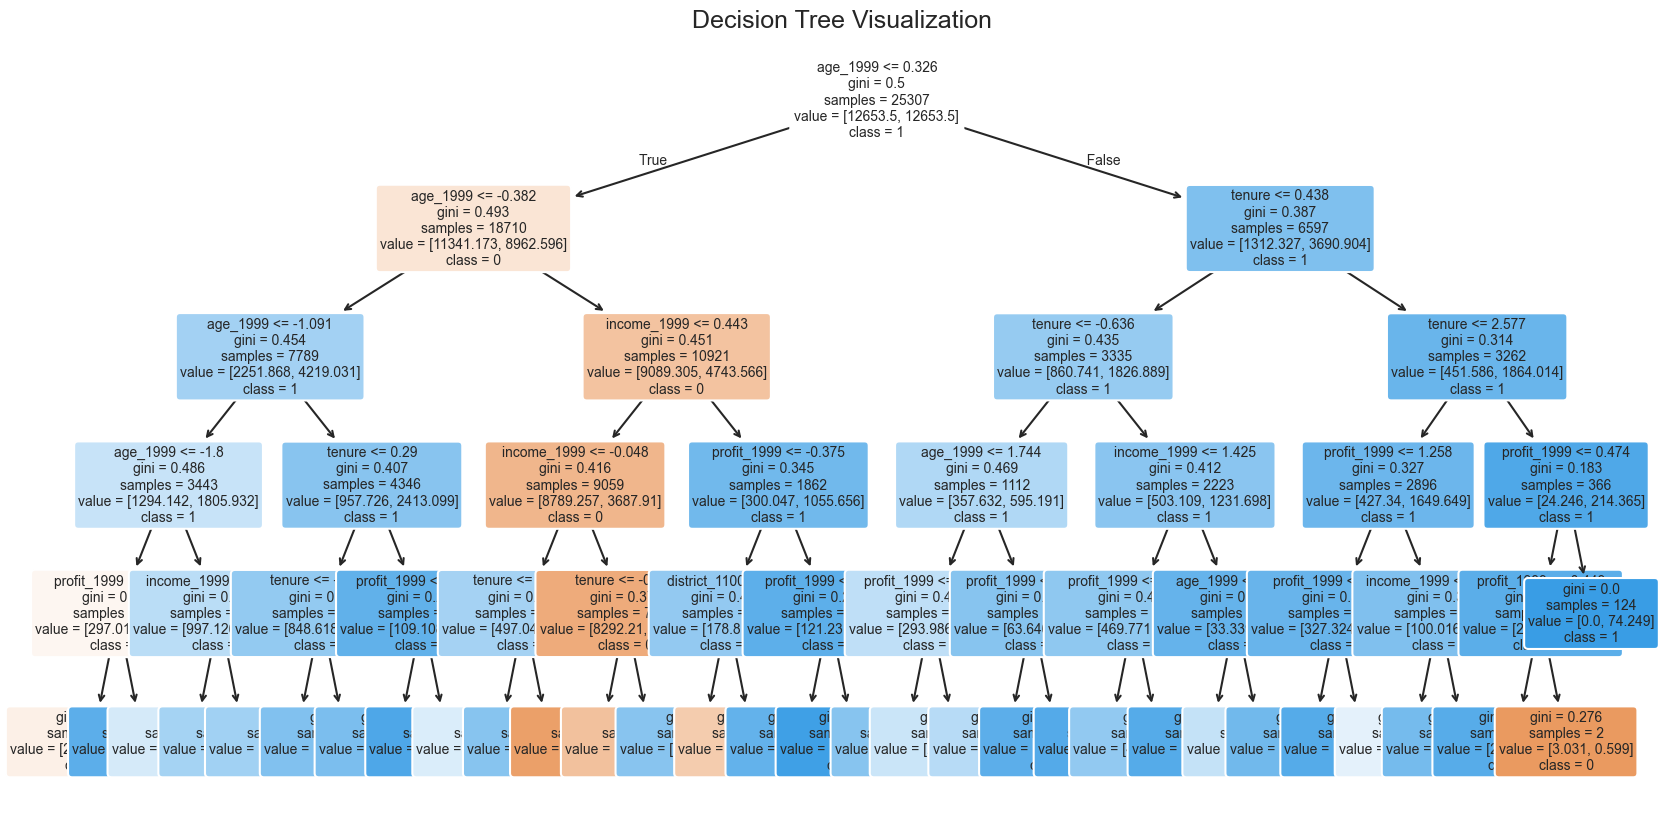

In [17]:
# Use plot_tree from sklearn.tree (plt is already imported earlier in the notebook)
from sklearn.tree import plot_tree

# Extract the fitted Decision Tree from the pipeline
dt_model = dt_best.named_steps["clf"]

# Get feature names after preprocessing
# numeric_features and categorical_features are defined earlier in the notebook
fitted_ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = fitted_ohe.get_feature_names_out(categorical_features)
feature_names = numeric_features + list(cat_feature_names)

# Plot the tree
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    feature_names=feature_names,
    class_names=[str(c) for c in dt_model.classes_],
    filled=True,
    rounded=True,
    fontsize=10,
)
plt.title("Decision Tree Visualization")
plt.show()

# Confision Matrix (Test Set)

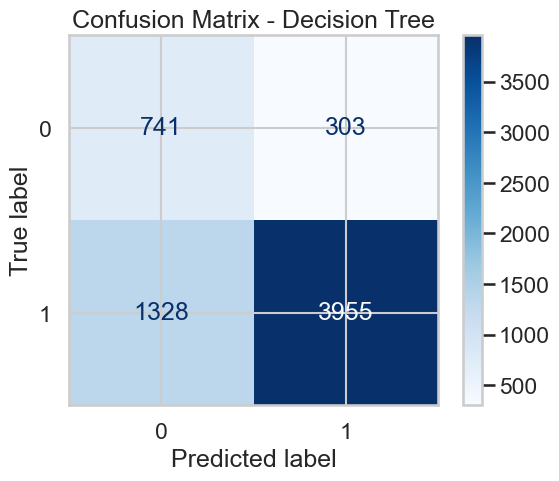

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_test_pred_dt = dt_best.predict(X_test)

cm = confusion_matrix(y_test, y_test_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=dt_model.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

# Feature Importance 

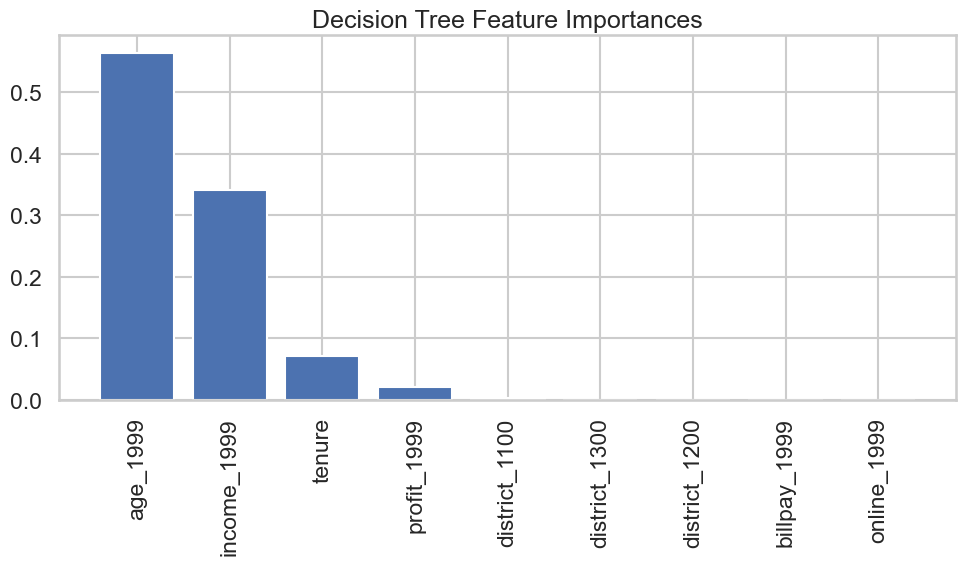

In [19]:
import numpy as np

importances = dt_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), np.array(feature_names)[indices], rotation=90)
plt.title("Decision Tree Feature Importances")
plt.tight_layout()
plt.show()

# 3.2 K-Nearest Neighbors

In [ ]:
# -------------------------
# K-Nearest Neighbors
# -------------------------
knn_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("clf", KNeighborsClassifier()),
    ]
)

knn_param_grid = {
    "clf__n_neighbors": [5, 15, 25],
    "clf__weights": ["uniform", "distance"],
    "clf__p": [1, 2],  # Manhattan vs Euclidean
}

knn_best = fit_and_evaluate_model("KNN", knn_pipe, knn_param_grid)


=== KNN: GridSearchCV ===
Best params: {'clf__n_neighbors': 25, 'clf__p': 2, 'clf__weights': 'uniform'}
Best CV AUC: 0.7373055540528484
KNN (Train+Val) -> ACC: 0.844, PREC: 0.860, REC: 0.971, F1: 0.912, AUC: 0.804
KNN (Test) -> ACC: 0.832, PREC: 0.856, REC: 0.961, F1: 0.906, AUC: 0.750


# Confusion Matrix (Test Set)

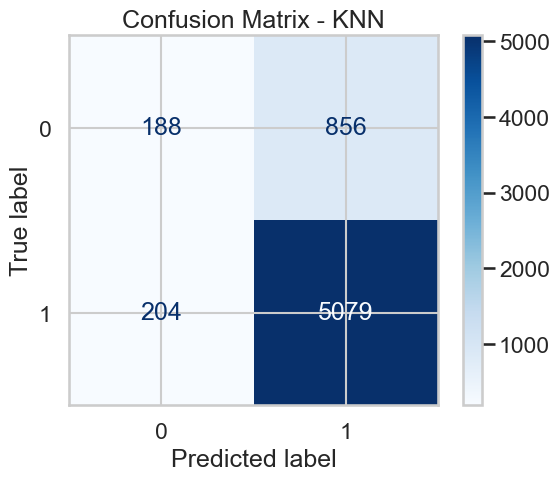

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_test_pred_knn = knn_best.predict(X_test)

cm = confusion_matrix(y_test, y_test_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=knn_best.named_steps["clf"].classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - KNN")
plt.show()

# ROC Curve & AUC (Binary Classification)

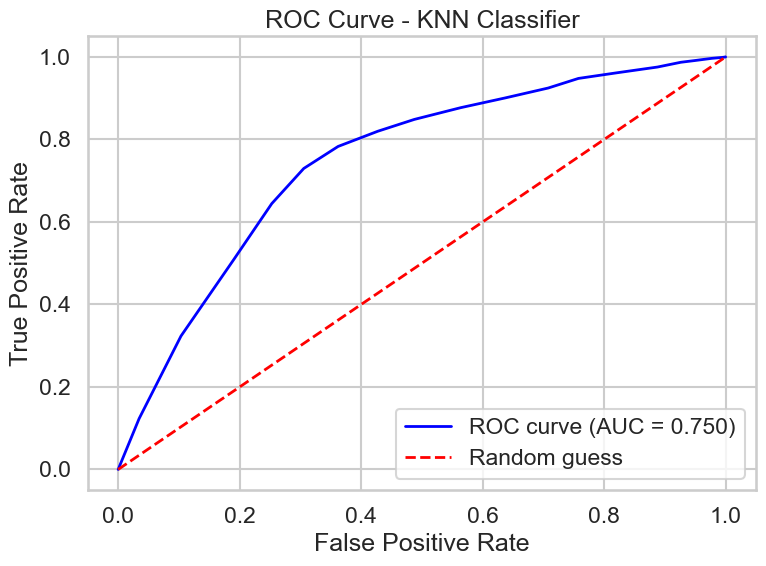

In [22]:
from sklearn.metrics import roc_curve, auc

# Get probabilities for positive class
y_test_proba_knn = knn_best.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba_knn)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], color="red", lw=2, linestyle="--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN Classifier")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Precision–Recall Curve (Imbalanced Data) 

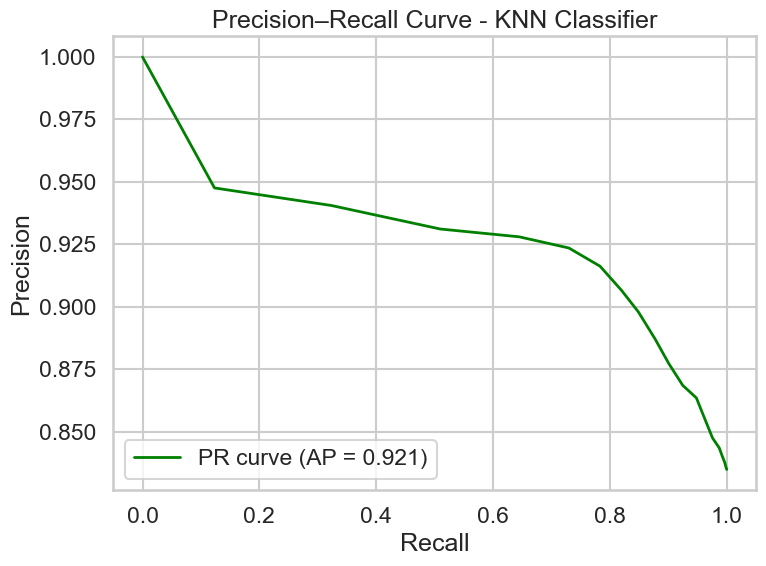

In [23]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, y_test_proba_knn)
avg_precision = average_precision_score(y_test, y_test_proba_knn)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, color="green", lw=2,
         label=f"PR curve (AP = {avg_precision:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve - KNN Classifier")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

# Decision Boundary (for 2D feature subsets)

d:\MMA 602\Sessions-tutorial\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


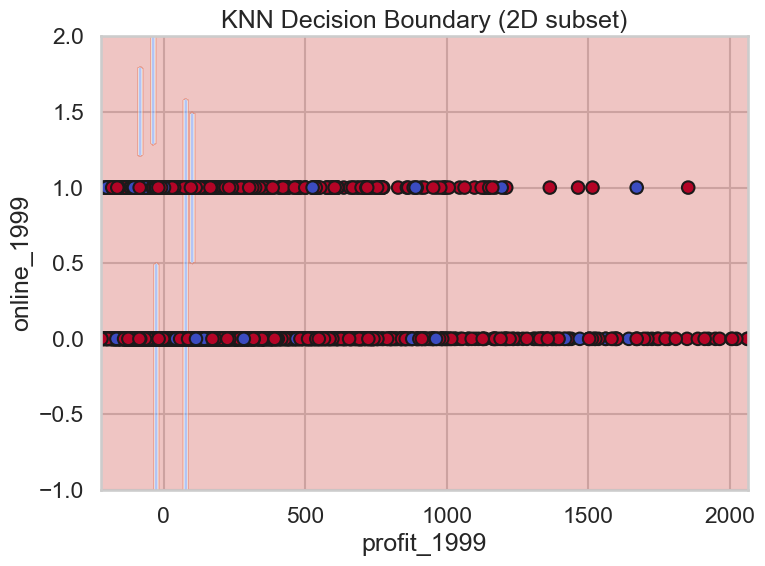

In [24]:
import numpy as np

# Select two features for visualization
feature_x, feature_y = X.columns[:2]  # replace with specific features
X_vis = X_test[[feature_x, feature_y]]
y_vis = y_test

# Fit a simplified KNN on just these two features
knn_vis = KNeighborsClassifier(n_neighbors=5)
knn_vis.fit(X_vis, y_vis)

# Create meshgrid
x_min, x_max = X_vis[feature_x].min()-1, X_vis[feature_x].max()+1
y_min, y_max = X_vis[feature_y].min()-1, X_vis[feature_y].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

Z = knn_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
plt.scatter(X_vis[feature_x], X_vis[feature_y], c=y_vis, edgecolor="k", cmap="coolwarm")
plt.xlabel(feature_x)
plt.ylabel(feature_y)
plt.title("KNN Decision Boundary (2D subset)")
plt.tight_layout()
plt.show()

# 3.3 Random Forest 

In [25]:
# -------------------------
#  Random Forest
# -------------------------
rf_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("clf", RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced",
        )),
    ]
)

rf_param_grid = {
    "clf__n_estimators": [200, 400],
    "clf__max_depth": [None, 10, 20],
    "clf__min_samples_split": [2, 20],
    "clf__min_samples_leaf": [1, 5],
}

rf_best = fit_and_evaluate_model("Random Forest", rf_pipe, rf_param_grid)


=== Random Forest: GridSearchCV ===
Best params: {'clf__max_depth': 10, 'clf__min_samples_leaf': 5, 'clf__min_samples_split': 20, 'clf__n_estimators': 400}
Best CV AUC: 0.7639758432267155
Random Forest (Train+Val) -> ACC: 0.775, PREC: 0.929, REC: 0.791, F1: 0.854, AUC: 0.840
Random Forest (Test) -> ACC: 0.763, PREC: 0.924, REC: 0.780, F1: 0.846, AUC: 0.767


# Random Forest: Confusion Matrix (Test Set)

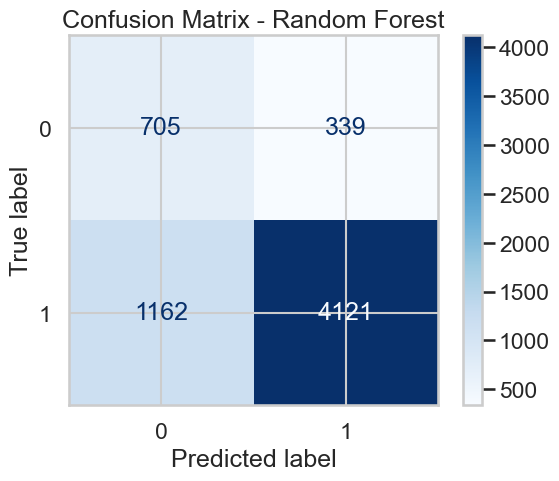

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_test_pred_rf = rf_best.predict(X_test)

cm = confusion_matrix(y_test, y_test_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=rf_best.named_steps["clf"].classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()

# ROC Curve & AUC (Binary Classification)

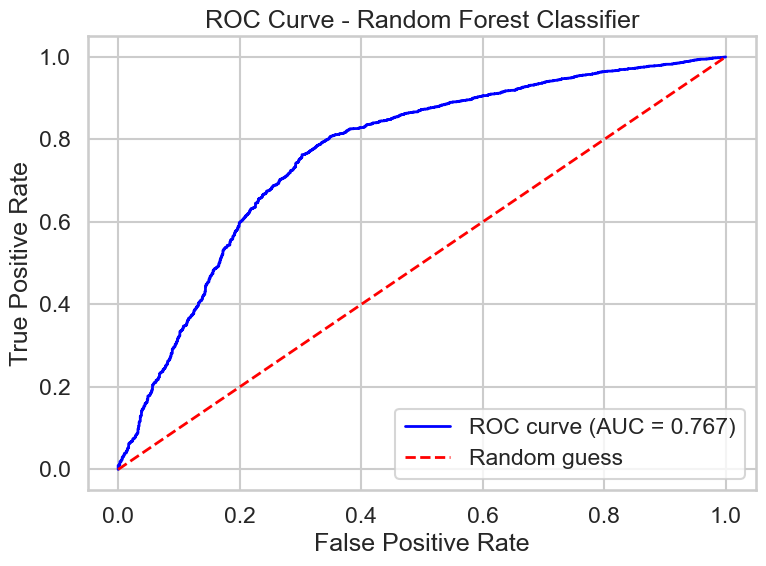

In [27]:
from sklearn.metrics import roc_curve, auc

y_test_proba_rf = rf_best.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba_rf)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], color="red", lw=2, linestyle="--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest Classifier")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Feature Importance

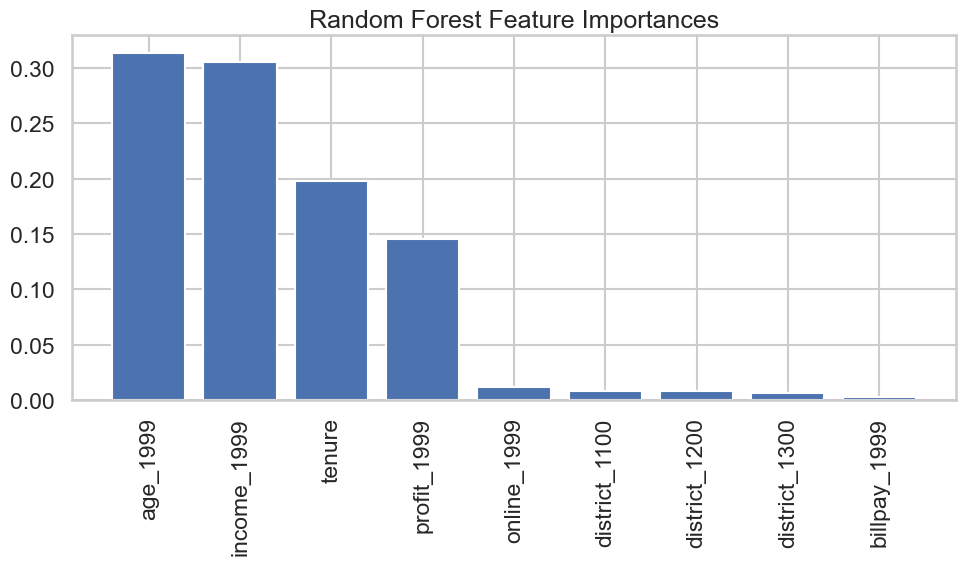

In [29]:
import numpy as np

rf_model = rf_best.named_steps["clf"]

# Get feature names after preprocessing
# Use named_transformers_ and the original feature lists to avoid calling dict() on 3-tuples
ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = ohe.get_feature_names_out(categorical_features) if "cat" in preprocessor.named_transformers_ else []
num_feature_names = numeric_features  # numeric_features defined earlier in the notebook

# Match preprocessing order: numeric features followed by one-hot encoded categorical features
feature_names = list(num_feature_names) + list(cat_feature_names)

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), np.array(feature_names)[indices], rotation=90)
plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()

# Precision–Recall Curve (Imbalanced Data)

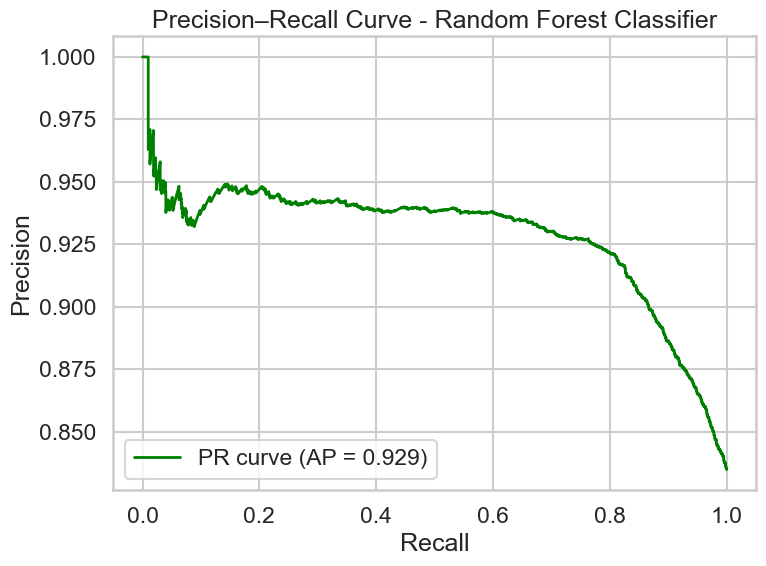

In [30]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, y_test_proba_rf)
avg_precision = average_precision_score(y_test, y_test_proba_rf)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, color="green", lw=2,
         label=f"PR curve (AP = {avg_precision:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve - Random Forest Classifier")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

# 3.4 Support Vector Machine (SVM)

In [31]:
# -------------------------
# Support Vector Machine (SVM)
# -------------------------
svm_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("clf", SVC(
            probability=True,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )),
    ]
)

svm_param_grid = {
    "clf__kernel": ["rbf"],
    "clf__C": [0.5, 1, 10],
    "clf__gamma": ["scale", 0.1, 0.01],
}

svm_best = fit_and_evaluate_model("SVM", svm_pipe, svm_param_grid)


=== SVM: GridSearchCV ===
Best params: {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
Best CV AUC: 0.7331730486663006
SVM (Train+Val) -> ACC: 0.700, PREC: 0.926, REC: 0.696, F1: 0.795, AUC: 0.761
SVM (Test) -> ACC: 0.686, PREC: 0.922, REC: 0.681, F1: 0.783, AUC: 0.732


# SVM Classifier: Confusion Matrix (Test Set)

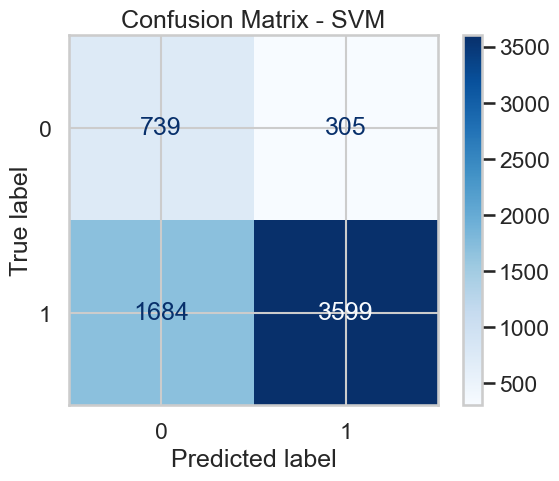

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_test_pred_svm = svm_best.predict(X_test)

cm = confusion_matrix(y_test, y_test_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=svm_best.named_steps["clf"].classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - SVM")
plt.show()

# ROC Curve & AUC (Binary Classification)

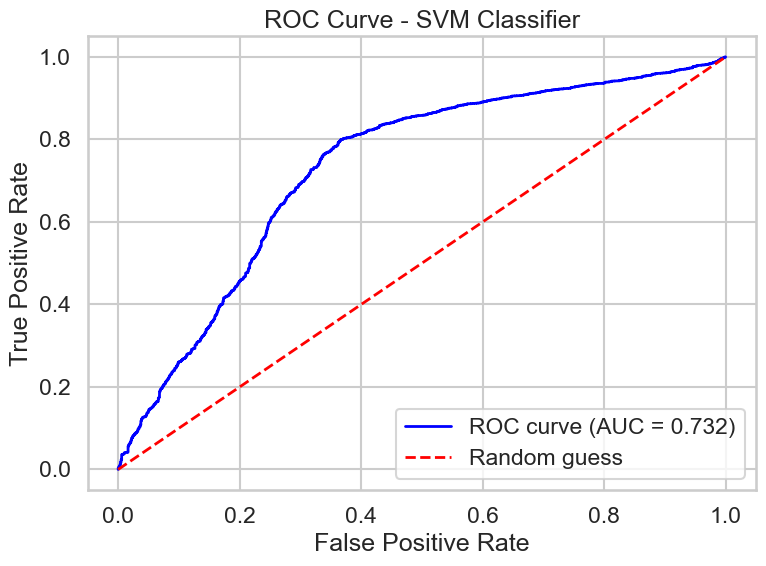

In [33]:
from sklearn.metrics import roc_curve, auc

y_test_proba_svm = svm_best.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba_svm)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], color="red", lw=2, linestyle="--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM Classifier")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Precision–Recall Curve

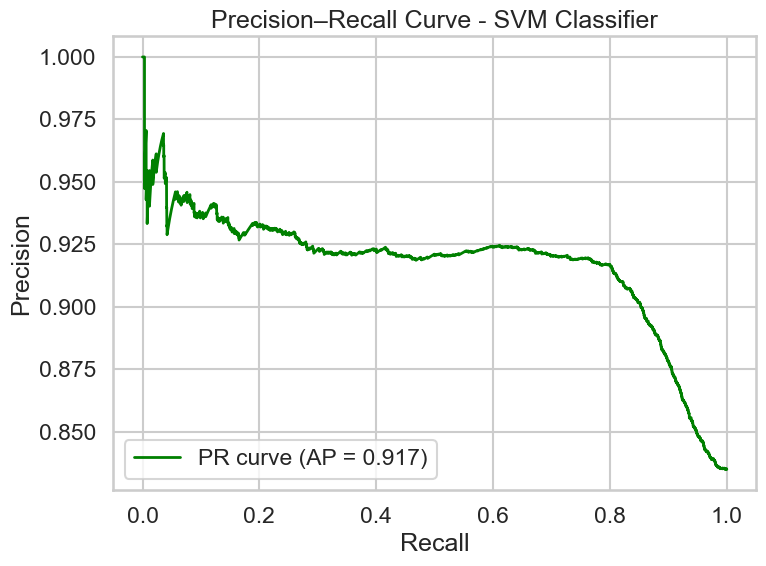

In [34]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, y_test_proba_svm)
avg_precision = average_precision_score(y_test, y_test_proba_svm)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, color="green", lw=2,
         label=f"PR curve (AP = {avg_precision:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve - SVM Classifier")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

#  Decision Boundary (for 2D feature subsets) 

d:\MMA 602\Sessions-tutorial\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


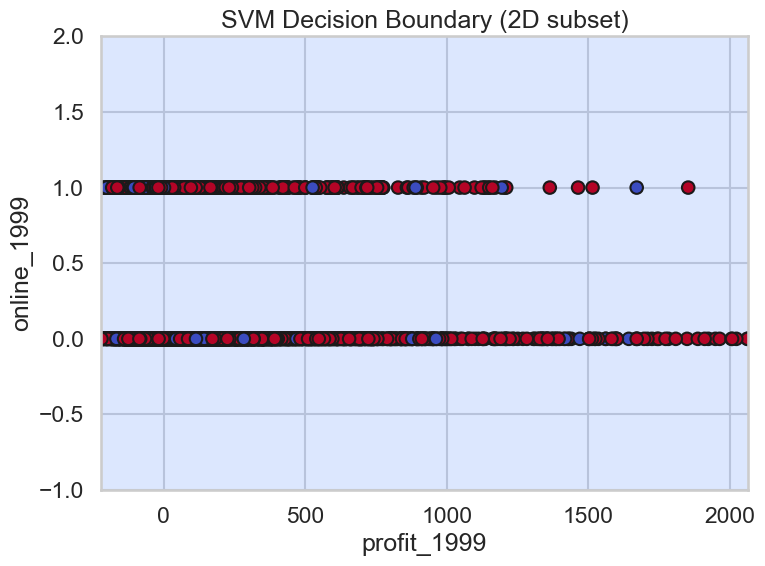

In [35]:
import numpy as np

# Select two features for visualization
feature_x, feature_y = X.columns[:2]  # replace with specific features
X_vis = X_test[[feature_x, feature_y]]
y_vis = y_test

# Fit a simplified SVM on just these two features
svm_vis = SVC(kernel="rbf", C=1, gamma="scale", probability=True)
svm_vis.fit(X_vis, y_vis)

# Create meshgrid
x_min, x_max = X_vis[feature_x].min()-1, X_vis[feature_x].max()+1
y_min, y_max = X_vis[feature_y].min()-1, X_vis[feature_y].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

Z = svm_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
plt.scatter(X_vis[feature_x], X_vis[feature_y], c=y_vis, edgecolor="k", cmap="coolwarm")
plt.xlabel(feature_x)
plt.ylabel(feature_y)
plt.title("SVM Decision Boundary (2D subset)")
plt.tight_layout()
plt.show()

# 3.5 XGBoost

In [36]:
# -------------------------
# 3.5 XGBoost
# -------------------------
xgb_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("clf", XGBClassifier(
            objective="binary:logistic",
            eval_metric="auc",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            scale_pos_weight=1.0,  # you can tune this based on class imbalance
        )),
    ]
)

xgb_param_grid = {
    "clf__n_estimators": [200, 400],
    "clf__max_depth": [3, 5, 8],
    "clf__learning_rate": [0.05, 0.1],
    "clf__subsample": [0.8, 1.0],
    "clf__colsample_bytree": [0.8, 1.0],
}

xgb_best = fit_and_evaluate_model("XGBoost", xgb_pipe, xgb_param_grid)



=== XGBoost: GridSearchCV ===
Best params: {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 200, 'clf__subsample': 0.8}
Best CV AUC: 0.7640140673926821
XGBoost (Train+Val) -> ACC: 0.841, PREC: 0.850, REC: 0.983, F1: 0.912, AUC: 0.781
XGBoost (Test) -> ACC: 0.838, PREC: 0.849, REC: 0.981, F1: 0.910, AUC: 0.764


# Confusion Matrix (Test Set)

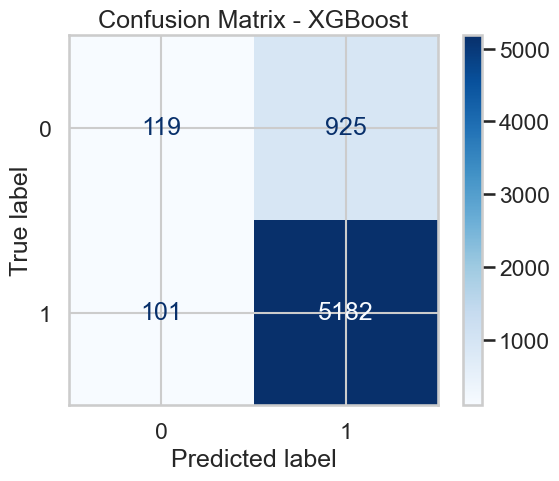

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_test_pred_xgb = xgb_best.predict(X_test)

cm = confusion_matrix(y_test, y_test_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=xgb_best.named_steps["clf"].classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - XGBoost")
plt.show()


# ROC Curve & AUC

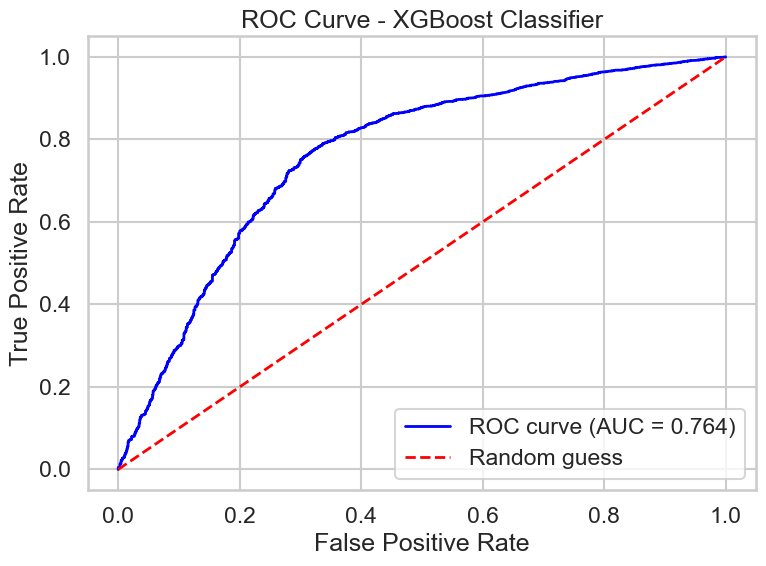

In [38]:
from sklearn.metrics import roc_curve, auc

y_test_proba_xgb = xgb_best.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba_xgb)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], color="red", lw=2, linestyle="--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost Classifier")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

#  Precision–Recall Curve 

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, y_test_proba_xgb)
avg_precision = average_precision_score(y_test, y_test_proba_xgb)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, color="green", lw=2,
         label=f"PR curve (AP = {avg_precision:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve - XGBoost Classifier")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

# Feature Importance 

<Figure size 1000x600 with 0 Axes>

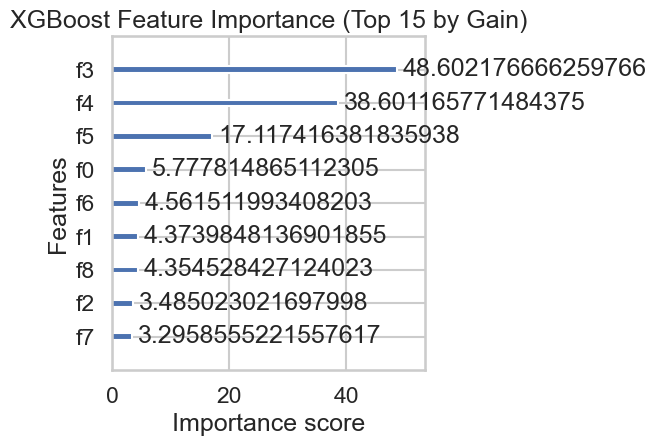

In [39]:
from xgboost import plot_importance

xgb_model = xgb_best.named_steps["clf"]

plt.figure(figsize=(10,6))
plot_importance(xgb_model, max_num_features=15, importance_type="gain")
plt.title("XGBoost Feature Importance (Top 15 by Gain)")
plt.tight_layout()
plt.show()

# Add baseline logistic regression to results for comparison

In [40]:
# Add baseline logistic regression to results for comparison
results.append(
    {
        "Model": "Logistic Regression (baseline)",
        "Train_Accuracy": baseline_train_metrics["Accuracy"],
        "Train_Precision": baseline_train_metrics["Precision"],
        "Train_Recall": baseline_train_metrics["Recall"],
        "Train_F1": baseline_train_metrics["F1"],
        "Train_AUC": baseline_train_metrics["AUC"],
        "Test_Accuracy": baseline_test_metrics["Accuracy"],
        "Test_Precision": baseline_test_metrics["Precision"],
        "Test_Recall": baseline_test_metrics["Recall"],
        "Test_F1": baseline_test_metrics["F1"],
        "Test_AUC": baseline_test_metrics["AUC"],
    }
)


# 4. Evaluation & Comparison

In [41]:
# ============================================
# 4. Evaluation & Comparison
# ============================================

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("Test_AUC", ascending=False)
print("\n=== Model Comparison (sorted by Test AUC) ===")
print(results_df[["Model", "Test_Accuracy", "Test_Precision", "Test_Recall", "Test_F1", "Test_AUC"]])


=== Model Comparison (sorted by Test AUC) ===
                            Model  Test_Accuracy  Test_Precision  Test_Recall  \
2                   Random Forest       0.762763        0.923991     0.780049   
4                         XGBoost       0.837838        0.848534     0.980882   
0                   Decision Tree       0.742216        0.928840     0.748628   
1                             KNN       0.832464        0.855771     0.961386   
3                             SVM       0.685633        0.921875     0.681242   
5  Logistic Regression (baseline)       0.532006        0.897603     0.496120   

    Test_F1  Test_AUC  
2  0.845941  0.767360  
4  0.909921  0.763878  
0  0.829054  0.763213  
1  0.905509  0.749597  
3  0.783498  0.731563  
5  0.639034  0.646065  


# 4.1 Bar plots for Test AUC and Test F1 

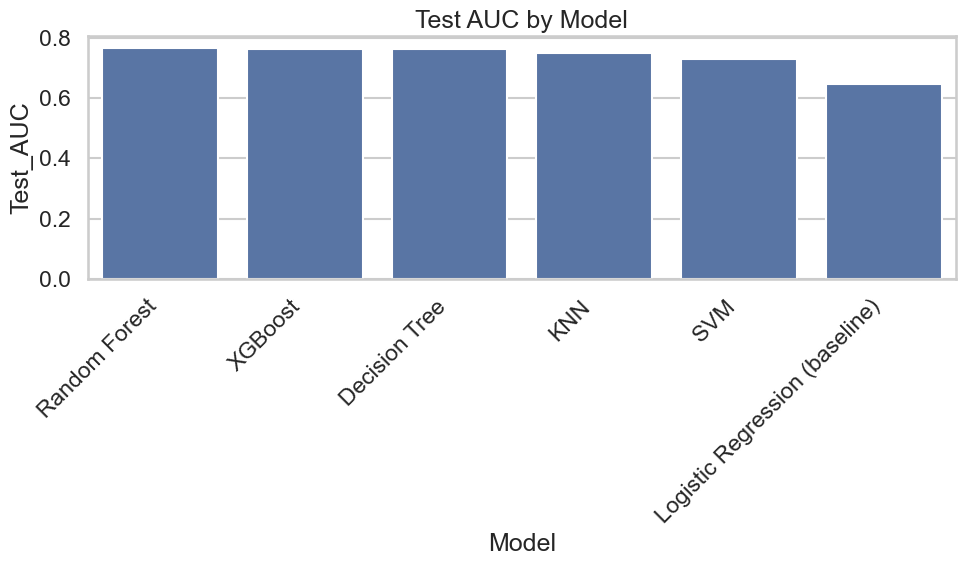

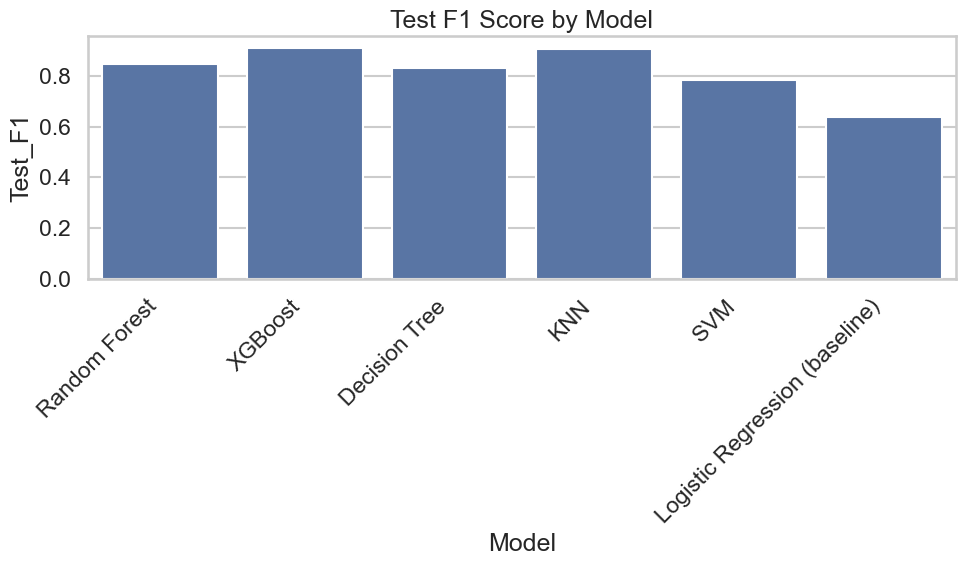

In [42]:
# 4.1 Bar plots for Test AUC and Test F1
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="Model", y="Test_AUC")
plt.xticks(rotation=45, ha="right")
plt.title("Test AUC by Model")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="Model", y="Test_F1")
plt.xticks(rotation=45, ha="right")
plt.title("Test F1 Score by Model")
plt.tight_layout()
plt.show()

# 4.2 Confusion matrix for best model (highest Test AUC) 


Best model by Test AUC: Random Forest


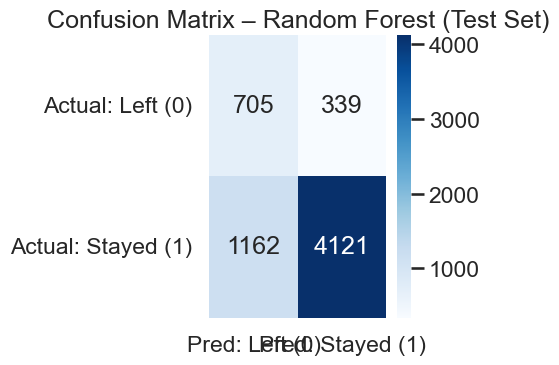

In [43]:
# 4.2 Confusion matrix for best model (highest Test AUC)
best_row = results_df.iloc[0]
best_model_name = best_row["Model"]
print("\nBest model by Test AUC:", best_model_name)

# Map name to fitted model object
name_to_model = {
    "Decision Tree": dt_best,
    "KNN": knn_best,
    "Random Forest": rf_best,
    "SVM": svm_best,
    "XGBoost": xgb_best,
    "Logistic Regression (baseline)": log_reg_pipe,
}
best_model = name_to_model[best_model_name]

y_test_best_pred = best_model.predict(X_test)
y_test_best_proba = best_model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_test_best_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred: Left (0)", "Pred: Stayed (1)"],
            yticklabels=["Actual: Left (0)", "Actual: Stayed (1)"])
plt.title(f"Confusion Matrix – {best_model_name} (Test Set)")
plt.tight_layout()
plt.show()


# 4.3 ROC Curve for best model vs baseline logistic regression 

d:\MMA 602\Sessions-tutorial\.venv\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


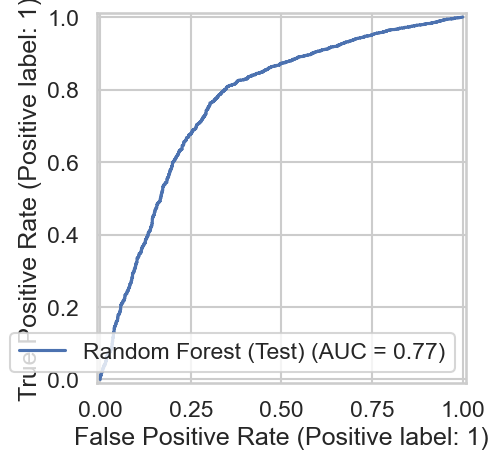

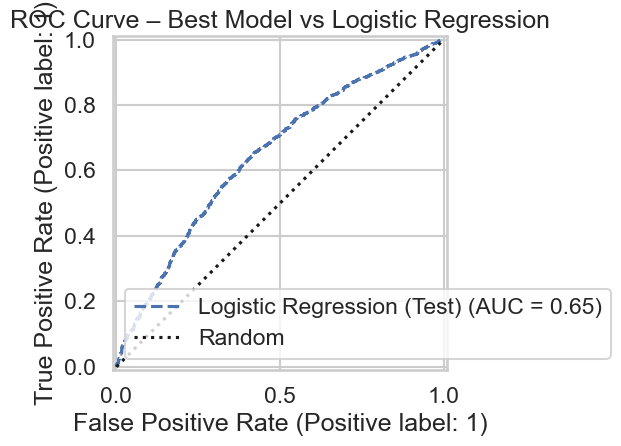

In [44]:
# 4.3 ROC Curve for best model vs baseline logistic regression
RocCurveDisplay.from_predictions(
    y_test, y_test_best_proba,
    name=f"{best_model_name} (Test)",
)

RocCurveDisplay.from_predictions(
    y_test, y_test_proba,
    name="Logistic Regression (Test)",
    linestyle="--",
)

plt.plot([0, 1], [0, 1], "k:", label="Random")
plt.title("ROC Curve – Best Model vs Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()

# 5. Interpretation: Feature importance (top model) 


Top 15 features for Random Forest:
         feature  importance
3       age_1999    0.313906
4    income_1999    0.305177
5         tenure    0.198217
0    profit_1999    0.145919
1    online_1999    0.011578
6  district_1100    0.007860
7  district_1200    0.007727
8  district_1300    0.006579
2   billpay_1999    0.003037


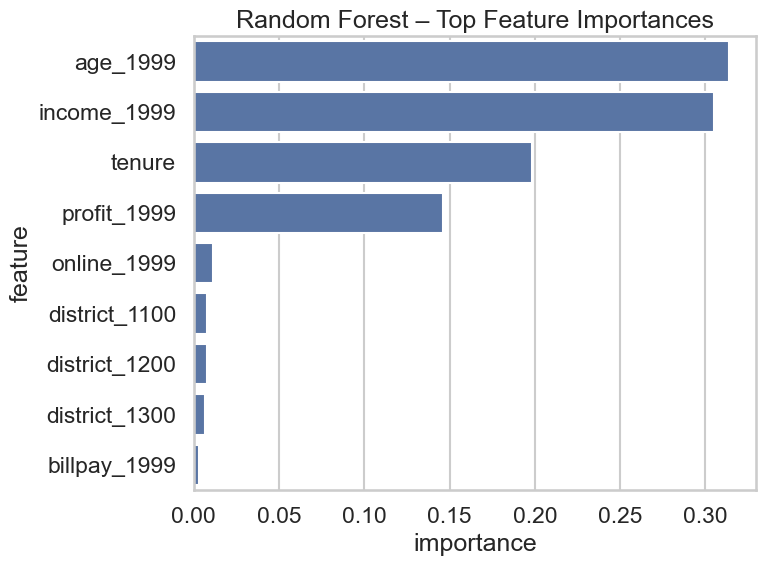

In [47]:
# ============================================
# 5. Interpretation: Feature importance (top model)
# ============================================

def get_feature_names_from_preprocessor(preprocessor, numeric_features, categorical_features):
    """
    Extract final feature names after ColumnTransformer.
    """
    feature_names = []

    # numeric
    feature_names.extend(numeric_features)

    # categorical (one-hot)
    cat_transformer = preprocessor.named_transformers_["cat"]
    ohe = cat_transformer.named_steps["onehot"]
    cat_names = ohe.get_feature_names_out(categorical_features).tolist()
    feature_names.extend(cat_names)
    return feature_names


if best_model_name in ["Random Forest", "XGBoost"]:
    # Extract feature importances
    base_preprocessor = best_model.named_steps["preprocessor"]
    clf = best_model.named_steps["clf"]

    feature_names = get_feature_names_from_preprocessor(
        base_preprocessor, numeric_features, categorical_features
    )

    importances = clf.feature_importances_
    fi_df = pd.DataFrame({"feature": feature_names, "importance": importances})
    fi_df = fi_df.sort_values("importance", ascending=False)

    print(f"\nTop 15 features for {best_model_name}:")
    print(fi_df.head(15))

    plt.figure(figsize=(8, 6))
    sns.barplot(data=fi_df.head(15), x="importance", y="feature")
    plt.title(f"{best_model_name} – Top Feature Importances")
    plt.tight_layout()
    plt.show()
else:
    print(f"\nBest model is {best_model_name}, which does not expose tree-based feature_importances_.")
    print("You can use permutation importance or SHAP separately if needed.")


#  6. Learning curve for best model

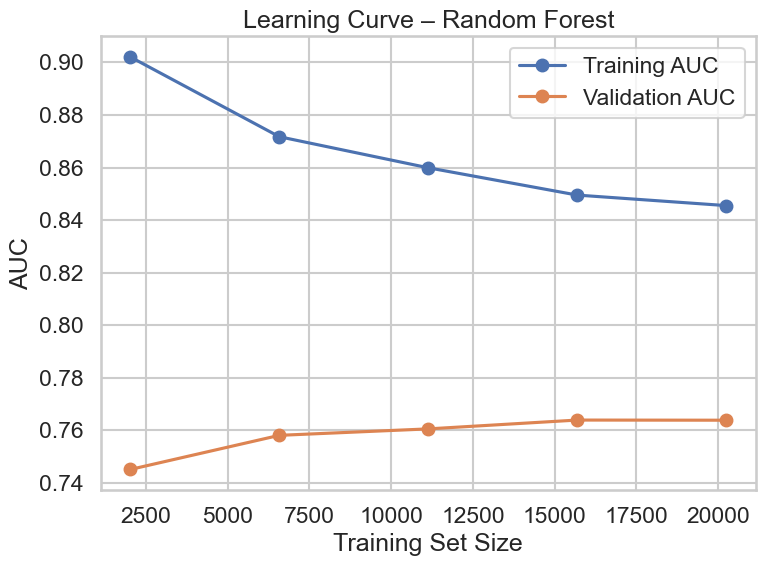

In [ ]:
# ============================================
# 6. Learning curve for best model 
# ============================================

train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X_train_val,
    y_train_val,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, marker="o", label="Training AUC")
plt.plot(train_sizes, val_mean, marker="o", label="Validation AUC")
plt.xlabel("Training Set Size")
plt.ylabel("AUC")
plt.title(f"Learning Curve – {best_model_name}")
plt.legend()
plt.tight_layout()
plt.show()

# Conclusions and Recommendations 
Based on this study, it can be concluded that nonlinear machine learning models significantly outperform logistic regression in predicting customer retention at Pilgrim Bank. XGBoost demonstrates the strongest recall and a high F1-score, while Random Forest provides the most balanced overall performance. The Appendix provides a comprehensive set of diagnostic charts that support these findings